# Bacillus posterior comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import seaborn as sns
from Bio import Phylo
import warnings
import torch
import torch.nn as nn
import sbi
from sbi.inference.posteriors.direct_posterior import DirectPosterior
from sbi.inference import NPE_C
import sys
sys.path.append('../pysimARG')

torch_device = "cpu"
warnings.filterwarnings("ignore", category=UserWarning)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load staph gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/bacillus/bacillus.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                                                      ____ 1
                                                                   __|
                                                                 _|  |____ 4
                                                                | |
                                                           _____| |_______ 12
                                                          |     |
                                                          |     |       __ 2
                                          ________________|     |______|
                                         |                |            |__ 11
                                         |                |
              ___________________________|                |_______________ 10
             |                           |
             |                           |                            ____ 3
             |                           |             ______________|
      

In [3]:
x_obs_info_table = pd.read_csv("../data/bacillus/bacillus_block_info.csv", index_col=0)
x_obs_info_table.head()

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
0_0,5247,71581,76827,True
0_1,5246,76828,82073,True
1,4191,67350,71540,True
2,2175,28543,30717,True
3,2401,142577,144977,True


In [4]:
x_obs_df = pd.read_csv("../data/bacillus/bacillus_block_summary_stats.csv", header=None)
x_obs_np = x_obs_df.to_numpy()
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([1277, 46]), torch.float32)

## Get posterior distributions from NPE models

In [5]:
num_posterior_samples = 1000
np.random.seed(100)

### NPE for rho+theta

In [6]:
checkpoint = torch.load(
    "../data/bacillus/trained_npe_density_estimator.pt",
    map_location=torch_device,
    weights_only=False,
)

density_estimator = checkpoint["density_estimator"]
prior = checkpoint["prior"]
density_estimator = density_estimator.to(torch_device)

posterior = DirectPosterior(
    posterior_estimator=density_estimator,
    prior=prior,
    device=torch_device,
)

In [7]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
theta_post.shape

(1277, 1000, 3)

In [8]:
for i in range(x_obs_torch.shape[0]):
    theta_post_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                        show_progress_bars=False, reject_outside_prior=False)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

In [9]:
theta_post_median = np.median(theta_post, axis=1)
theta_post_median.shape

(1277, 3)

#### Load conditional posterior dataset

In [10]:
theta_post_cond = np.load("../data/bacillus/conditional_posterior_samples.npy")
theta_post_cond.shape

(1277, 1000, 2)

In [11]:
theta_post_cond_median = np.median(theta_post_cond, axis=1)
theta_post_cond_median.shape

(1277, 2)

### NPE for rho only

In [12]:
checkpoint_rho_only = torch.load(
    "../data/bacillus/trained_npe_density_estimator_2d.pt",
    map_location=torch_device,
    weights_only=False,
)

density_estimator_rho_only = checkpoint_rho_only["density_estimator"]
prior_rho_only = checkpoint_rho_only["prior"]
density_estimator_rho_only = density_estimator_rho_only.to(torch_device)

posterior_rho_only = DirectPosterior(
    posterior_estimator=density_estimator_rho_only,
    prior=prior_rho_only,
    device=torch_device,
)

In [13]:
theta_post_rho_only = np.full((x_obs_torch.shape[0], num_posterior_samples, 2), np.nan)
theta_post_rho_only.shape

(1277, 1000, 2)

In [14]:
for i in range(x_obs_torch.shape[0]):
    theta_post_torch = posterior_rho_only.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                                show_progress_bars=False, reject_outside_prior=False)
    theta_post_rho_only[i, :, :] = theta_post_torch.cpu().detach().numpy()

In [15]:
theta_post_rho_only_median = np.median(theta_post_rho_only, axis=1)
theta_post_rho_only_median.shape

(1277, 2)

### NPE for rho+theta with summary NN

In [16]:
class LeaveLengthOut_NN(nn.Module):
    def __init__(self, input_dim=46, num_hiddens=50):
        super().__init__()
        
        # This MLP generates the first 3 features. 
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, num_hiddens),
            nn.ReLU(),
            nn.Linear(num_hiddens, num_hiddens),
            nn.ReLU(),
            nn.Linear(num_hiddens, 4)  # Output exactly 4 neurons
        )

    def forward(self, x):
        # 1. Get the 4 neurons from the MLP
        mlp_out = self.mlp(x)
        # 2. Extract the last element of the input vector
        last_element = x[:, -1:] 
        # 3. Concatenate them along the feature dimension
        out = torch.cat([mlp_out, last_element], dim=-1)
        
        return out

In [18]:
checkpoint_NN = torch.load(
    "../data/bacillus/trained_npe_density_estimator_NN.pt",
    map_location=torch_device,
    weights_only=False,
)

density_estimator_NN = checkpoint_NN["density_estimator"]
prior_NN = checkpoint_NN["prior"]
density_estimator_NN = density_estimator_NN.to(torch_device)

posterior_NN = DirectPosterior(
    posterior_estimator=density_estimator_NN,
    prior=prior_NN,
    device=torch_device,
)

In [19]:
theta_post_NN = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
theta_post_NN.shape

(1277, 1000, 3)

In [20]:
for i in range(x_obs_torch.shape[0]):
    theta_post_torch = posterior_NN.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                           show_progress_bars=False, reject_outside_prior=False)
    theta_post_NN[i, :, :] = theta_post_torch.cpu().detach().numpy()

In [21]:
theta_post_NN_median = np.median(theta_post_NN, axis=1)
theta_post_NN_median.shape

(1277, 3)

### NPE for rho+theta in log scale

In [23]:
theta_post_log_median = np.load("../data/bacillus/log_posterior_median.npy")
theta_post_log_median.shape

(1277, 3)

## Comparison figures

### Recombination rate

In [24]:
diag_min = np.min(theta_post_median[:, 0])
diag_max = np.max(theta_post_median[:, 0])

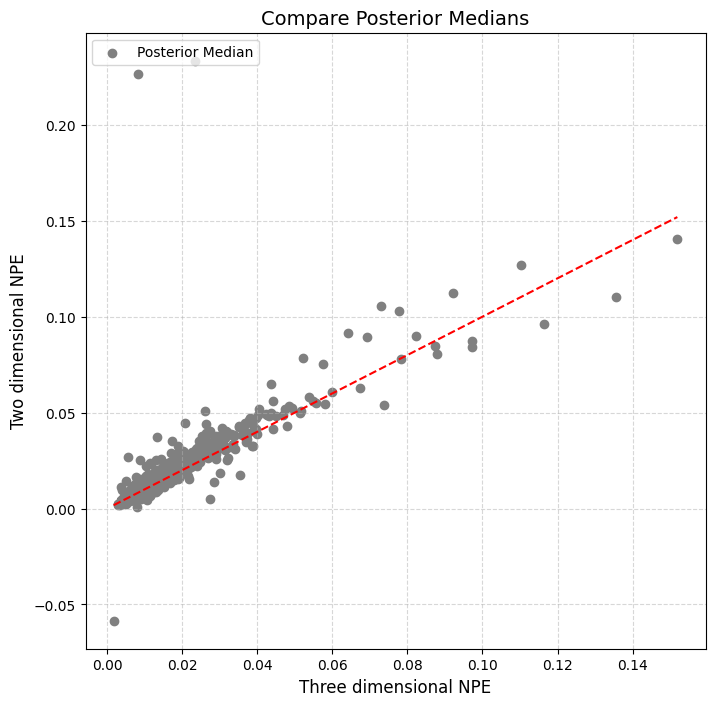

In [25]:
plt.figure(figsize=(8, 8))
plt.scatter(theta_post_median[:, 0], theta_post_rho_only_median[:, 0], color='gray', label='Posterior Median')

exact_x = np.linspace(diag_min, diag_max, 400)
exact_y = exact_x

plt.title("Compare Posterior Medians", fontsize=14)
plt.xlabel("Three dimensional NPE", fontsize=12)
plt.ylabel("Two dimensional NPE", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

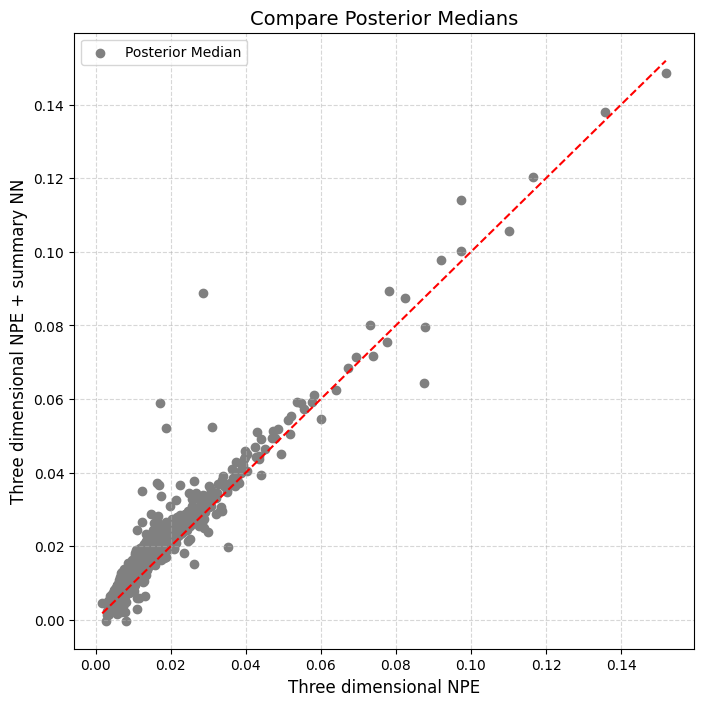

In [26]:
plt.figure(figsize=(8, 8))
plt.scatter(theta_post_median[:, 0], theta_post_NN_median[:, 0], color='gray', label='Posterior Median')

exact_x = np.linspace(diag_min, diag_max, 400)
exact_y = exact_x

plt.title("Compare Posterior Medians", fontsize=14)
plt.xlabel("Three dimensional NPE", fontsize=12)
plt.ylabel("Three dimensional NPE + summary NN", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

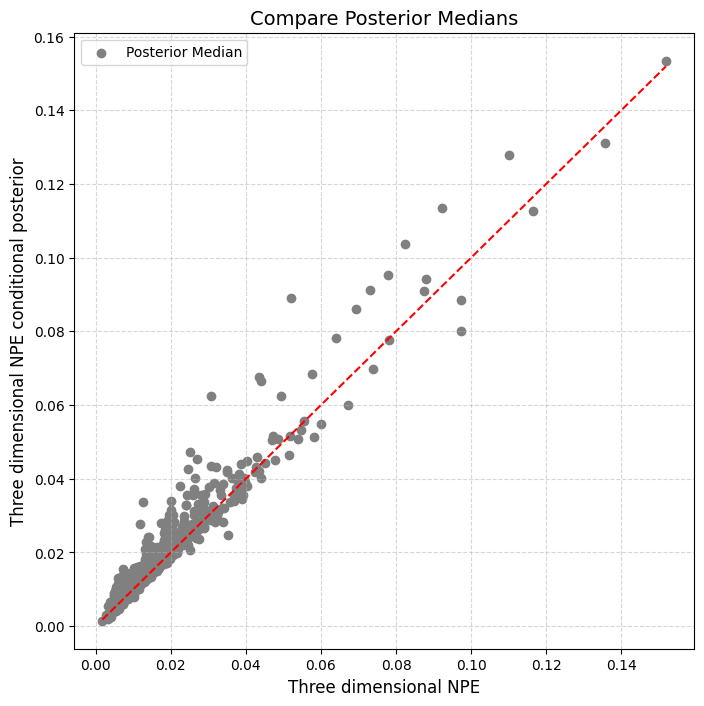

In [27]:
plt.figure(figsize=(8, 8))
plt.scatter(theta_post_median[:, 0], theta_post_cond_median[:, 0], color='gray', label='Posterior Median')

exact_x = np.linspace(diag_min, diag_max, 400)
exact_y = exact_x

plt.title("Compare Posterior Medians", fontsize=14)
plt.xlabel("Three dimensional NPE", fontsize=12)
plt.ylabel("Three dimensional NPE conditional posterior", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

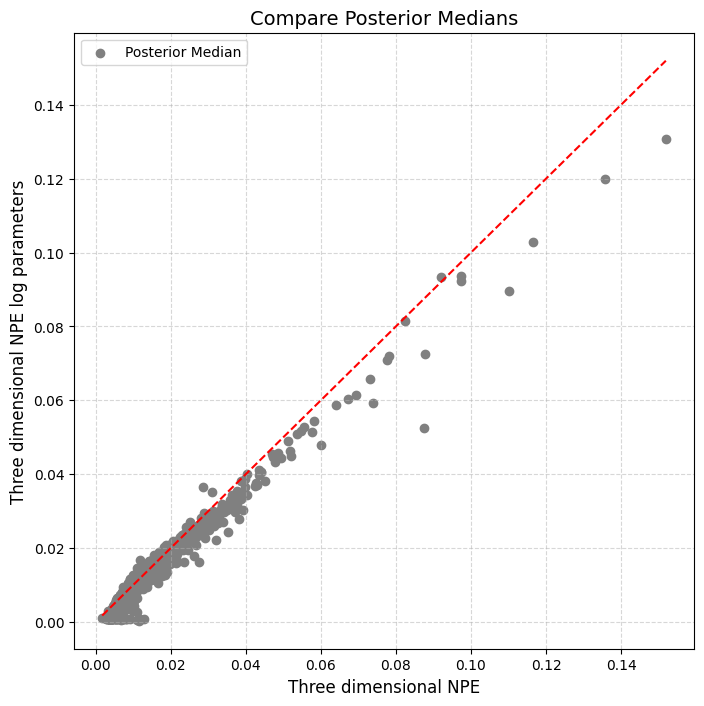

In [28]:
plt.figure(figsize=(8, 8))
plt.scatter(theta_post_median[:, 0], np.exp(theta_post_log_median[:, 0]), color='gray', label='Posterior Median')

exact_x = np.linspace(diag_min, diag_max, 400)
exact_y = exact_x

plt.title("Compare Posterior Medians", fontsize=14)
plt.xlabel("Three dimensional NPE", fontsize=12)
plt.ylabel("Three dimensional NPE log parameters", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

### Mutation rate

In [29]:
diag_min = np.min(theta_post_median[:, 1])
diag_max = np.max(theta_post_median[:, 1])

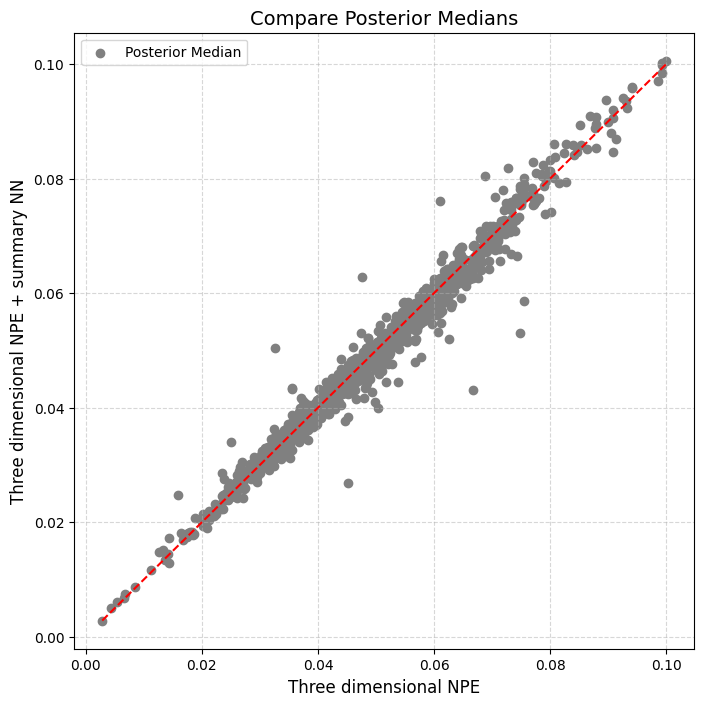

In [30]:
plt.figure(figsize=(8, 8))
plt.scatter(theta_post_median[:, 1], theta_post_NN_median[:, 1], color='gray', label='Posterior Median')

exact_x = np.linspace(diag_min, diag_max, 400)
exact_y = exact_x

plt.title("Compare Posterior Medians", fontsize=14)
plt.xlabel("Three dimensional NPE", fontsize=12)
plt.ylabel("Three dimensional NPE + summary NN", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

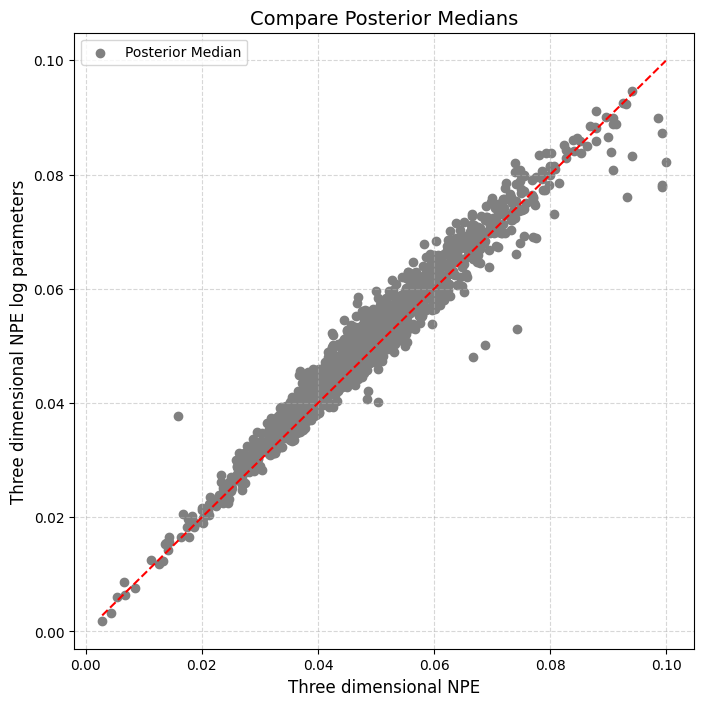

In [31]:
plt.figure(figsize=(8, 8))
plt.scatter(theta_post_median[:, 1], np.exp(theta_post_log_median[:, 1]), color='gray', label='Posterior Median')

exact_x = np.linspace(diag_min, diag_max, 400)
exact_y = exact_x

plt.title("Compare Posterior Medians", fontsize=14)
plt.xlabel("Three dimensional NPE", fontsize=12)
plt.ylabel("Three dimensional NPE log parameters", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

### Gene length

In [32]:
diag_min = np.min(theta_post_median[:, 2])
diag_max = np.max(theta_post_median[:, 2])

In [33]:
samples_l = x_obs_info_table['Gene_Length'].values
samples_l.shape

(1277,)

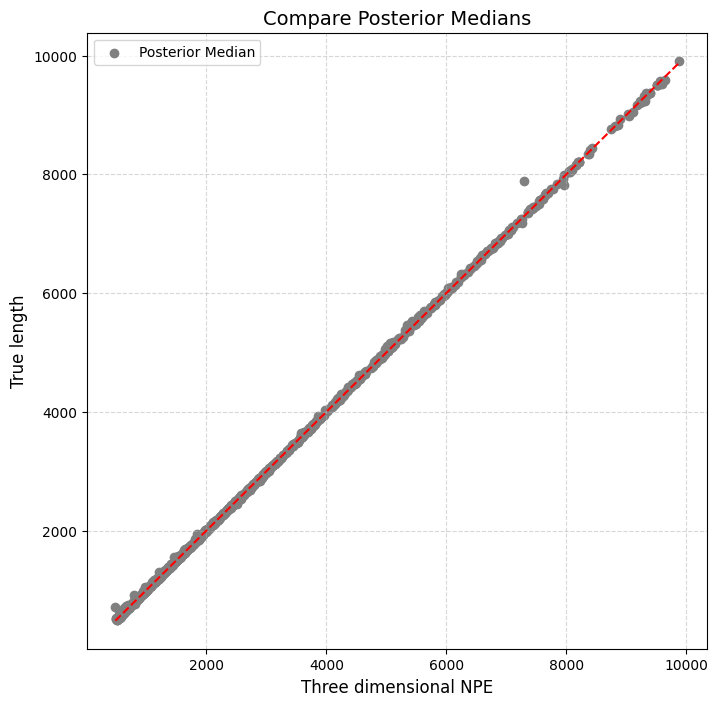

In [35]:
plt.figure(figsize=(8, 8))
plt.scatter(theta_post_median[:, 2], samples_l, color='gray', label='Posterior Median')

exact_x = np.linspace(diag_min, diag_max, 400)
exact_y = exact_x

plt.title("Compare Posterior Medians", fontsize=14)
plt.xlabel("Three dimensional NPE", fontsize=12)
plt.ylabel("True length", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

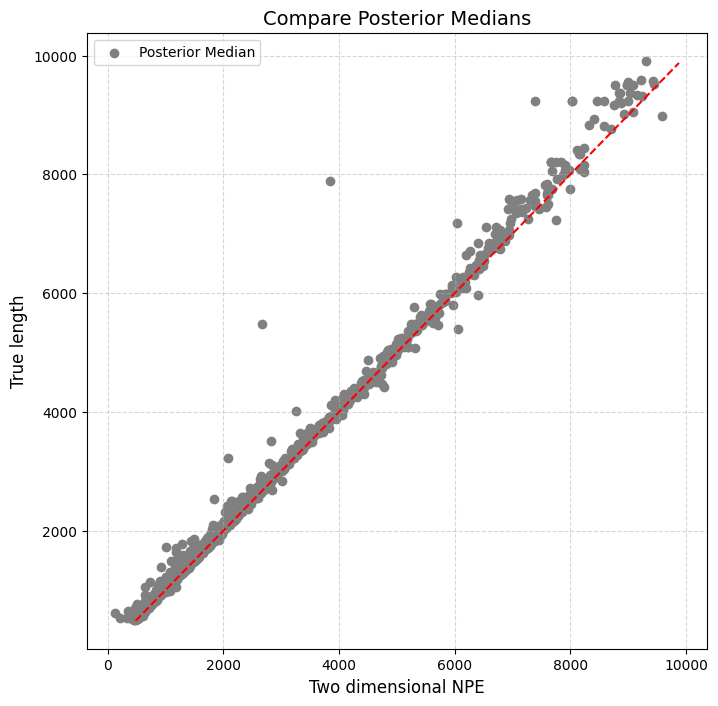

In [36]:
plt.figure(figsize=(8, 8))
plt.scatter(theta_post_rho_only_median[:, 1], samples_l, color='gray', label='Posterior Median')

exact_x = np.linspace(diag_min, diag_max, 400)
exact_y = exact_x

plt.title("Compare Posterior Medians", fontsize=14)
plt.xlabel("Two dimensional NPE", fontsize=12)
plt.ylabel("True length", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

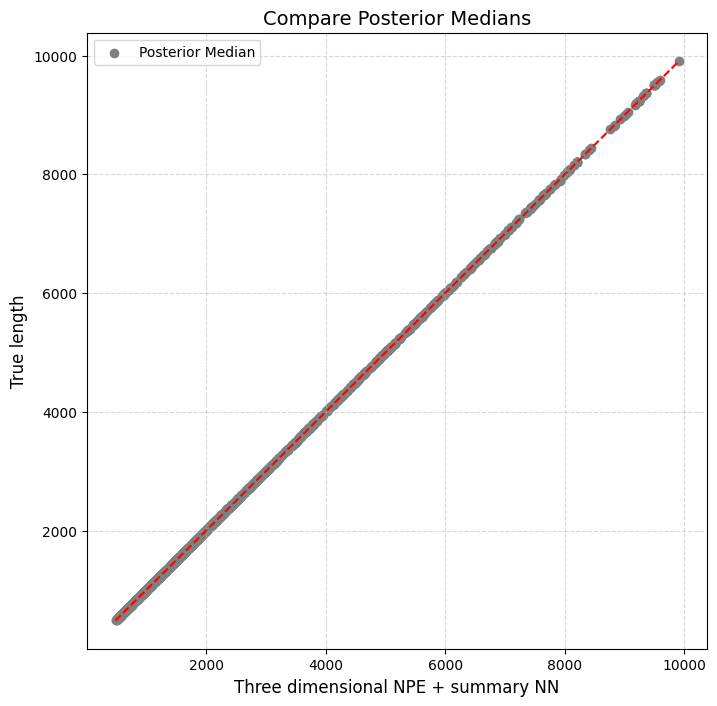

In [37]:
plt.figure(figsize=(8, 8))
plt.scatter(theta_post_NN_median[:, 2], samples_l, color='gray', label='Posterior Median')

exact_x = np.linspace(diag_min, diag_max, 400)
exact_y = exact_x

plt.title("Compare Posterior Medians", fontsize=14)
plt.xlabel("Three dimensional NPE + summary NN", fontsize=12)
plt.ylabel("True length", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

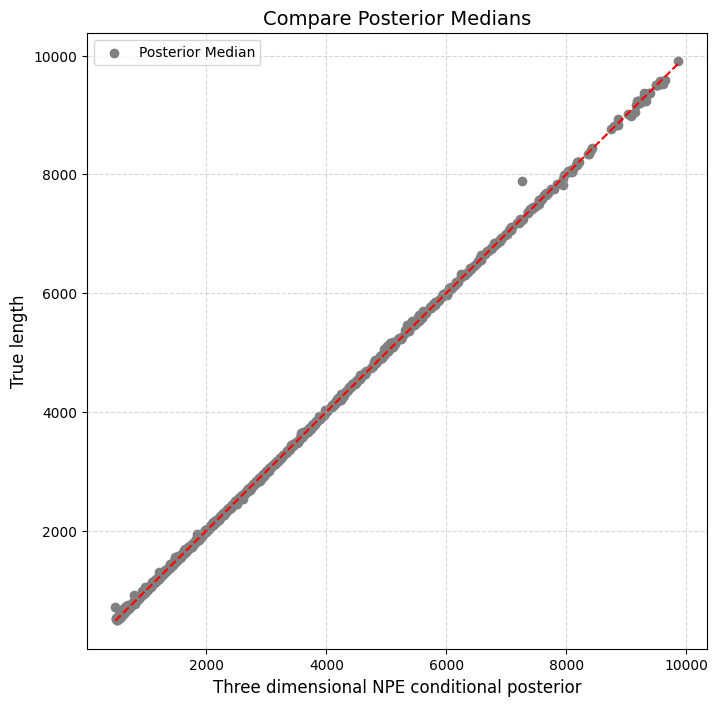

In [38]:
plt.figure(figsize=(8, 8))
plt.scatter(theta_post_cond_median[:, 1], samples_l, color='gray', label='Posterior Median')

exact_x = np.linspace(diag_min, diag_max, 400)
exact_y = exact_x

plt.title("Compare Posterior Medians", fontsize=14)
plt.xlabel("Three dimensional NPE conditional posterior", fontsize=12)
plt.ylabel("True length", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

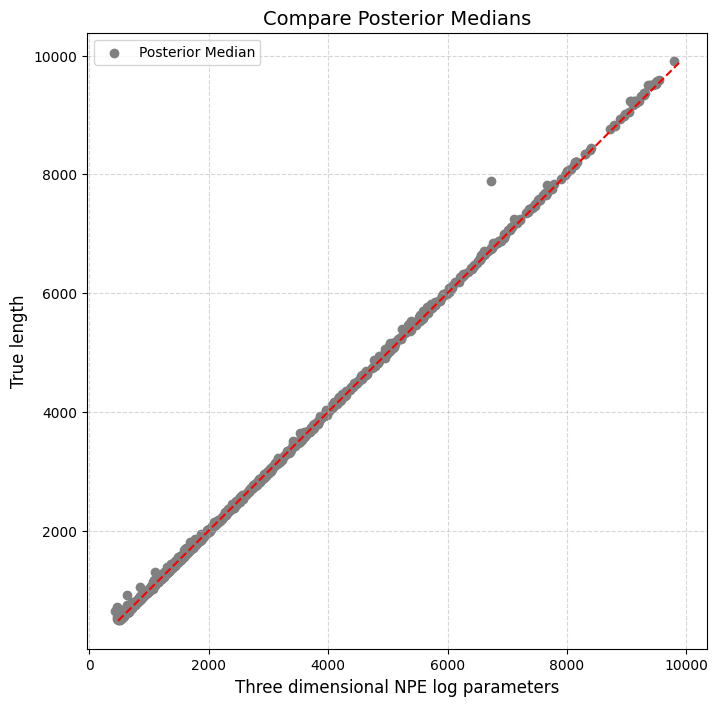

In [39]:
plt.figure(figsize=(8, 8))
plt.scatter(theta_post_log_median[:, 2], samples_l, color='gray', label='Posterior Median')

exact_x = np.linspace(diag_min, diag_max, 400)
exact_y = exact_x

plt.title("Compare Posterior Medians", fontsize=14)
plt.xlabel("Three dimensional NPE log parameters", fontsize=12)
plt.ylabel("True length", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()